# ML Config — Significant Taxa Only

Loads the master feature table built by `ml_00_prepare_feature_table.ipynb`
and the shared pipeline functions in `ml_pipeline_utils.py`. This notebook
only selects which columns to use (Step 3) - all data cleaning happened once,
upstream, in the prep notebook.

**Keep `ml_pipeline_utils.py` in the same folder as this notebook**, or add
its folder to `sys.path` before importing.



In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

# sys.path.append("/path/to/folder/containing/ml_pipeline_utils.py")  # uncomment and edit if needed
from ml_pipeline_utils import (
    RANDOM_STATE, check_platform_leakage, run_hyperparameter_search,
    run_loso_evaluation, plot_confusion_matrix, run_shap_analysis, save_artifacts, scale_within_platform,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder


## Step 1 - Load the master feature table and column lists

In [2]:
# ---- EDIT THESE PATHS ----
# FEATURE_TABLE_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/processed/ml_feature_table")
# OUTPUT_DIR = Path("/rds/projects/e/elhamsak-pd-thesis/results/ml_config_sig_taxa_only")
FEATURE_TABLE_DIR = Path("ml_feature_table")
OUTPUT_DIR = Path("ml_config1_all_taxa")
# ---------------------------

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

master = pd.read_csv(FEATURE_TABLE_DIR / "ml_master_feature_table.csv", index_col=0)

def load_list(path):
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]

all_taxa_columns         = load_list(FEATURE_TABLE_DIR / "all_taxa_columns.txt")
significant_taxa_columns = load_list(FEATURE_TABLE_DIR / "significant_taxa_columns.txt")
clinical_columns         = load_list(FEATURE_TABLE_DIR / "clinical_columns.txt")
pathway_columns          = load_list(FEATURE_TABLE_DIR / "pathway_columns.txt")

print("Master table:", master.shape)
print(master["disease_group"].value_counts())


Master table: (1831, 751)
disease_group
HC    756
PD    752
AD    323
Name: count, dtype: int64


## Step 2 - Confirm the master table is what you expect

In [3]:
assert master[all_taxa_columns].isna().sum().sum() == 0, "Unexpected NaNs in taxa columns"
assert master[clinical_columns].isna().sum().sum() == 0, "Unexpected NaNs in clinical columns"
assert master[pathway_columns].isna().sum().sum() == 0, "Unexpected NaNs in pathway columns"
print("No unexpected NaNs found in the feature blocks - good to proceed.")


No unexpected NaNs found in the feature blocks - good to proceed.


## Step 3 - Select this notebook's feature set

Just the ANCOM-BC2-significant genera union (PD-specific + AD-specific + shared).


In [ ]:
feature_cols = significant_taxa_columns
print(f"Using {len(feature_cols)} significant-taxa features.")

Using 43 significant-taxa features.


In [14]:
# building feature cols for only shared taxa: 
shared_taxa = ["g__Enterococcus", "g__Roseburia", "g__Haemophilus", "g__Clostridium", "g__Faecalibacterium", "g__Eisenbergiella", "g__Lachnospira"]
# Match either direct column names, 'taxon__<name>', or stripped genus names
feature_cols = []
for taxon in shared_taxa:
    clean_name = taxon.replace("g__", "")
    matched = [
        col for col in all_taxa_columns 
        if col == taxon 
        or col == f"taxon__{taxon}" 
        or col == f"taxon__{clean_name}" 
        or col == clean_name
    ]
    if matched:
        feature_cols.append(matched[0])
    else:
        print(f"WARNING: Taxon '{taxon}' not found in all_taxa_columns!")

print(f"Using {len(feature_cols)} shared taxa features: {feature_cols}")
assert len(feature_cols) == len(shared_taxa), f"Expected {len(shared_taxa)} features, but matched {len(feature_cols)}."

Using 7 shared taxa features: ['taxon__g__Enterococcus', 'taxon__g__Roseburia', 'taxon__g__Haemophilus', 'taxon__g__Clostridium', 'taxon__g__Faecalibacterium', 'taxon__g__Eisenbergiella', 'taxon__g__Lachnospira']


## Step 4 - Platform-leakage sanity check (diagnostic, not the real model)

Checks whether this exact feature set can trivially separate PD vs AD before
the real 3-class model runs. Given this project's documented platform
confound (100% shotgun vs 100% 16S), a near-perfect AUC here is a red flag,
not a result to celebrate.


In [15]:
check_platform_leakage(master, feature_cols)


PD-vs-AD study-grouped 5-fold AUC using 7 features: 0.624 +/- 0.200


(np.float64(0.6237869748321117), np.float64(0.20002649151704455))

In [16]:
hc_only = master[master["disease_group"] == "HC"]
platforms = hc_only["platform"].unique()
print("HC samples by platform:", hc_only["platform"].value_counts().to_dict())

if len(platforms) >= 2:
    check_platform_leakage(hc_only, feature_cols, disease_col="platform",
                            classes=tuple(platforms[:2]))
else:
    print("Only one platform present among HC samples - can't run this diagnostic.")

HC samples by platform: {'shotgun': 462, '16S': 294}
shotgun-vs-16S study-grouped 5-fold AUC using 7 features: 0.501 +/- 0.266


## Step 5 - Prepare X, y, groups

In [17]:
label_encoder = LabelEncoder()
master["y"] = label_encoder.fit_transform(master["disease_group"])
print("Class encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X = master[feature_cols].values
y = master["y"].values
groups = master["study_id"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# scaling platforms separately:
# X_scaled, platform_scalers = scale_within_platform(master, feature_cols, platform_col="platform")

print(f"Final feature count: {len(feature_cols)}")


Class encoding: {'AD': np.int64(0), 'HC': np.int64(1), 'PD': np.int64(2)}
Final feature count: 7


## Step 6 - Hyperparameter search (StratifiedGroupKFold)

In [18]:
grid = run_hyperparameter_search(X_scaled, y, groups)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 300}
Best CV f1_macro: 0.35446346919397925


## Step 7 - LOSO evaluation (this is the number for the thesis)

In [19]:
loso_df, all_y_true, all_y_pred = run_loso_evaluation(
    X_scaled, y, groups, grid.best_params_, label_encoder, OUTPUT_DIR
)


Fold 0 (held out bedarf2017): n=59, classes_present=2/3, F1_macro=0.385
Fold 1 (held out binyinli2019): n=60, classes_present=2/3, F1_macro=0.156
Fold 2 (held out boktor2023_rumc): n=114, classes_present=2/3, F1_macro=0.563
Fold 3 (held out boktor2023_tbc): n=113, classes_present=2/3, F1_macro=0.476
Fold 4 (held out cirstea2022): n=98, classes_present=2/3, F1_macro=0.268
Fold 5 (held out clasen2024): n=126, classes_present=2/3, F1_macro=0.298
Fold 6 (held out ling2021): n=171, classes_present=2/3, F1_macro=0.182
Fold 7 (held out liu2019): n=61, classes_present=2/3, F1_macro=0.243
Fold 8 (held out mao2021): n=78, classes_present=2/3, F1_macro=0.368
Fold 9 (held out ueda2021): n=7, classes_present=1/3, F1_macro=0.083
Fold 10 (held out wallen2022): n=724, classes_present=2/3, F1_macro=0.368
Fold 11 (held out yamashiro2024): n=37, classes_present=2/3, F1_macro=0.168
Fold 12 (held out yildirim2022): n=97, classes_present=2/3, F1_macro=0.171
Fold 13 (held out zhuang2018): n=86, classes_prese

## Step 8 - Pooled confusion matrix

     AD   HC   PD
AD   24  139  160
HC   84  445  227
PD  102  227  423


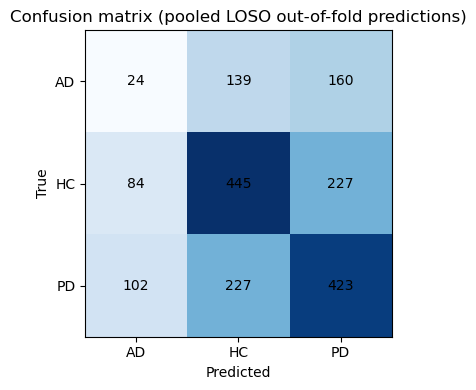

              precision    recall  f1-score   support

          AD       0.11      0.07      0.09       323
          HC       0.55      0.59      0.57       756
          PD       0.52      0.56      0.54       752

    accuracy                           0.49      1831
   macro avg       0.40      0.41      0.40      1831
weighted avg       0.46      0.49      0.47      1831



In [20]:
cm_df = plot_confusion_matrix(all_y_true, all_y_pred, label_encoder, OUTPUT_DIR)


## Step 9 - Final model + SHAP (interpretation only, not a performance claim)

`final_model` is fit on all data and used only for SHAP - performance metrics
come from the LOSO loop above.


In [21]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(**grid.best_params_, class_weight="balanced",
                                      random_state=RANDOM_STATE, n_jobs=-1)
final_model.fit(X_scaled, y)

shap_values = run_shap_analysis(final_model, X_scaled, feature_cols, label_encoder, OUTPUT_DIR,
                                 max_display=30 if len(feature_cols) > 40 else None)


Generating SHAP beeswarm for class: AD


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

## Step 10 - Save artefacts

In [ ]:
save_artifacts(final_model, scaler, label_encoder, feature_cols, OUTPUT_DIR)
